In [23]:
%matplotlib inline
import pandas as pd
import numpy as np
import joblib
from datetime import datetime


In [24]:
# Load test data 
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")  

# For real-time simulation, we can iterate over each sample
test_df = pd.DataFrame(X_test)

In [25]:
import numpy as np
import pandas as pd

# Load test data
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")  

# Create DataFrame for simulation
test_df = pd.DataFrame(X_test)

print("test_df created:", test_df.shape)


test_df created: (25195, 41)


In [26]:
import joblib

rf_model = joblib.load("ids_rf_model.pkl")
print("Models loaded")

Models loaded


In [27]:
from datetime import datetime

# Predict ALL samples at once
y_pred_rf = rf_model.predict(X_test)    #type:ignore

alerts = []

for i, pred in enumerate(y_pred_rf):
    if pred != 0:  # 0 = normal
        alerts.append({
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "sample_index": i,
            "predicted_attack_type": pred
        })

print("Total alerts generated:", len(alerts))



Total alerts generated: 15999


In [28]:
import pandas as pd

# Convert alerts list to DataFrame
alerts_df = pd.DataFrame(alerts)          #type:ignore

# Safety check
if alerts_df.empty:
    print("No intrusions detected.")
else:
    print("Intrusions detected:", len(alerts_df))

# Save to CSV (for dashboard / logs)
alerts_df.to_csv("real_time_alerts.csv", index=False)

# Save readable log file
with open("real_time_alerts.log", "w") as f:
    for _, row in alerts_df.iterrows():
        f.write(
            f"{row['timestamp']} | "
            f"Sample {row['sample_index']} | "
            f"Attack Type {row['predicted_attack_type']}\n"
        )

alerts_df.head()


Intrusions detected: 15999


,timestamp,sample_index,predicted_attack_type
0,2025-12-20 23:12:12,2,4
1,2025-12-20 23:12:12,3,1
2,2025-12-20 23:12:12,4,4
3,2025-12-20 23:12:12,5,4
4,2025-12-20 23:12:12,6,4


In [29]:
# Count attacks by type
attack_summary = alerts_df['predicted_attack_type'].value_counts()

print("Attack Summary:")
attack_summary


Attack Summary:


predicted_attack_type
4    13481
1     2325
2      193
Name: count, dtype: int64

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import os


In [31]:
print(" Intrusion Detection System - Notebook Dashboard")
# LOAD ALERT DATA

FILE_PATH = "real_time_alerts.csv"

if os.path.exists(FILE_PATH):
    alerts_df = pd.read_csv(FILE_PATH)
else:
    alerts_df = pd.DataFrame(
        columns=["timestamp", "sample_index", "predicted_attack_type"]
    )

# Convert timestamp
if not alerts_df.empty:
    alerts_df["timestamp"] = pd.to_datetime(alerts_df["timestamp"], errors="coerce")
# KPI SECTION

print("\n SYSTEM SUMMARY")

total_alerts = len(alerts_df)
unique_attacks = alerts_df["predicted_attack_type"].nunique() if not alerts_df.empty else 0
last_alert_time = (
    alerts_df["timestamp"].max()
    if not alerts_df.empty else "N/A"
)

print(f"Total Alerts        : {total_alerts}")
print(f"Unique Attack Types : {unique_attacks}")
print(f"Last Alert Time     : {last_alert_time}")

# ALERT LOG TABLE (TEXT VIEW)

print("\n INTRUSION ALERT LOGS (Last 10 rows)")
print("-" * 55)

if alerts_df.empty:
    print("No alerts recorded yet.")
else:
    print(alerts_df.tail(10).to_string(index=False))



 Intrusion Detection System - Notebook Dashboard

 SYSTEM SUMMARY
Total Alerts        : 15999
Unique Attack Types : 3
Last Alert Time     : 2025-12-20 23:12:12

 INTRUSION ALERT LOGS (Last 10 rows)
-------------------------------------------------------
          timestamp  sample_index  predicted_attack_type
2025-12-20 23:12:12         25180                      4
2025-12-20 23:12:12         25181                      4
2025-12-20 23:12:12         25183                      4
2025-12-20 23:12:12         25185                      4
2025-12-20 23:12:12         25186                      4
2025-12-20 23:12:12         25187                      4
2025-12-20 23:12:12         25189                      4
2025-12-20 23:12:12         25191                      4
2025-12-20 23:12:12         25192                      4
2025-12-20 23:12:12         25194                      1



 Attack Type Distribution


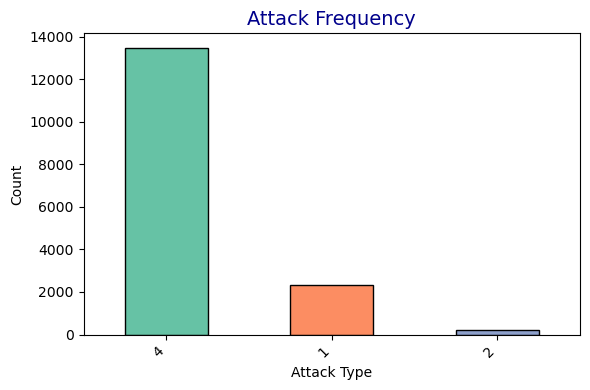


 Alert Trend (Sample-Based)


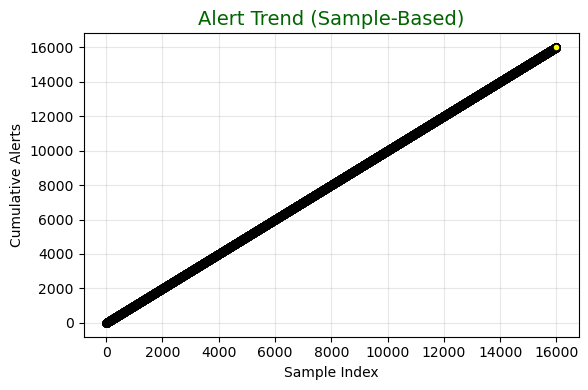


 Traffic Overview


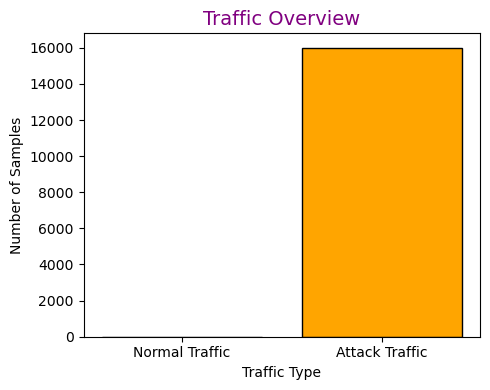

In [32]:
# VISUALIZATIONS 
import matplotlib.pyplot as plt
import seaborn as sns

if not alerts_df.empty:
    
    print("\n Attack Type Distribution")  #  Attack Type Distribution

    attack_counts = alerts_df["predicted_attack_type"].value_counts()

    plt.figure(figsize=(6, 4))
    colors = sns.color_palette("Set2", len(attack_counts))  
    attack_counts.plot(kind="bar", color=colors, edgecolor='black')
    plt.xlabel("Attack Type")
    plt.ylabel("Count")
    plt.title("Attack Frequency", fontsize=14, color='darkblue')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    plt.close()
    
    print("\n Alert Trend (Sample-Based)")  # Alert Trend (Sample-Based)

    plt.figure(figsize=(6, 4))
    plt.plot(
        range(len(alerts_df)),
        range(1, len(alerts_df) + 1),
        marker="o",
        linewidth=2,
        color='crimson',  
        markersize=5,
        markerfacecolor='yellow',
        markeredgecolor='black'
    )
    plt.xlabel("Sample Index")
    plt.ylabel("Cumulative Alerts")
    plt.title("Alert Trend (Sample-Based)", fontsize=14, color='darkgreen')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()

    print("\n Traffic Overview")  # Traffic Overview

    alerts_df["predicted_attack_type"] = (
        alerts_df["predicted_attack_type"]
        .astype(str)
        .str.lower()
        .str.strip()
    )

    normal_count = (alerts_df["predicted_attack_type"] == "normal").sum()
    attack_count = (alerts_df["predicted_attack_type"] != "normal").sum()

    plt.figure(figsize=(5, 4))
    plt.bar(
        ["Normal Traffic", "Attack Traffic"],
        [normal_count, attack_count],
        color=['skyblue', 'orange'],
        edgecolor='black'
    )
    plt.xlabel("Traffic Type")
    plt.ylabel("Number of Samples")
    plt.title("Traffic Overview", fontsize=14, color='purple')
    plt.tight_layout()
    plt.show()
    plt.close()

else:
    print("\n No intrusion alerts detected yet.")
